# Hands-On Agentic GraphRAG
# Notebook 3: GraphRAG — Local and Global Retrieval with Gemini

---
**Workshop series:** GraphRAG for Autonomous Incident Investigation  
**Prerequisites:** Notebook 2 — Introduction to Knowledge Graphs (must have run export cell to produce `incident_knowledge_graph.graphml`)  
**Runtime:** Google Colab - GPU

---

## Introduction

In Notebook 2 we proved that graph traversal can answer all queries that Vector RAG failed on. But those traversals were hand-coded — we wrote explicit Python for each question. A real system cannot do that. An engineer asking a natural-language question needs the system to figure out *which* nodes to start from, *how many hops* to expand, and *what context* to pass to the LLM on its own.

That is what **GraphRAG** does. It is a fully automated pipeline that takes any natural-language question, retrieves the relevant portion of the knowledge graph, and generates a grounded answer with Gemini — no hand-coded traversal required.

This notebook implements two complementary retrieval strategies:


---

### Part A — Local GraphRAG


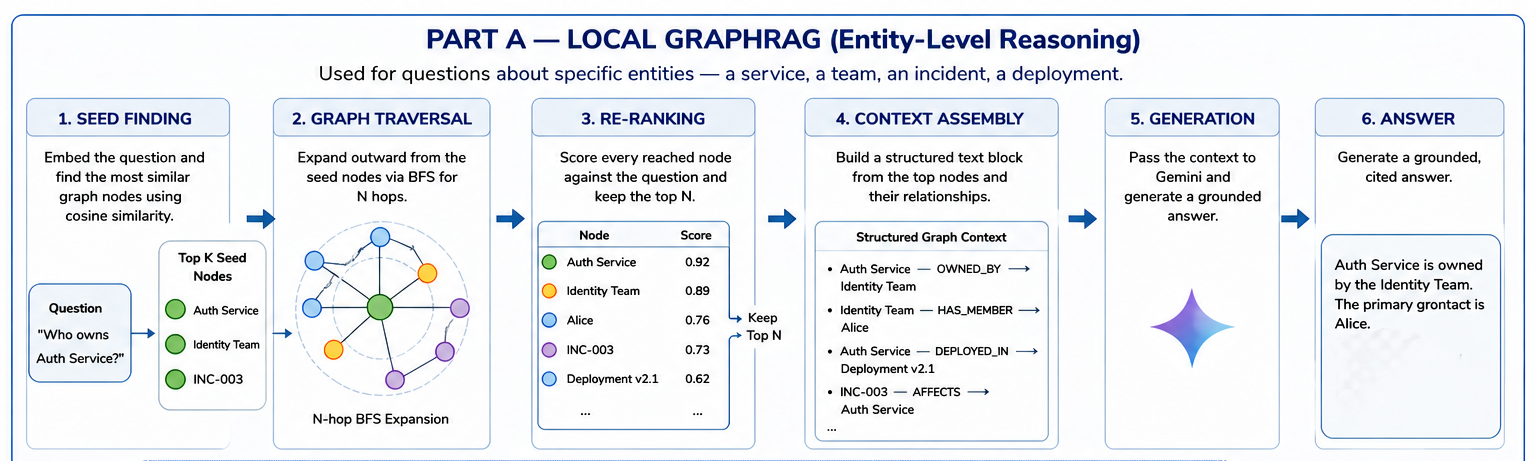


---

### Part B — Global GraphRAG


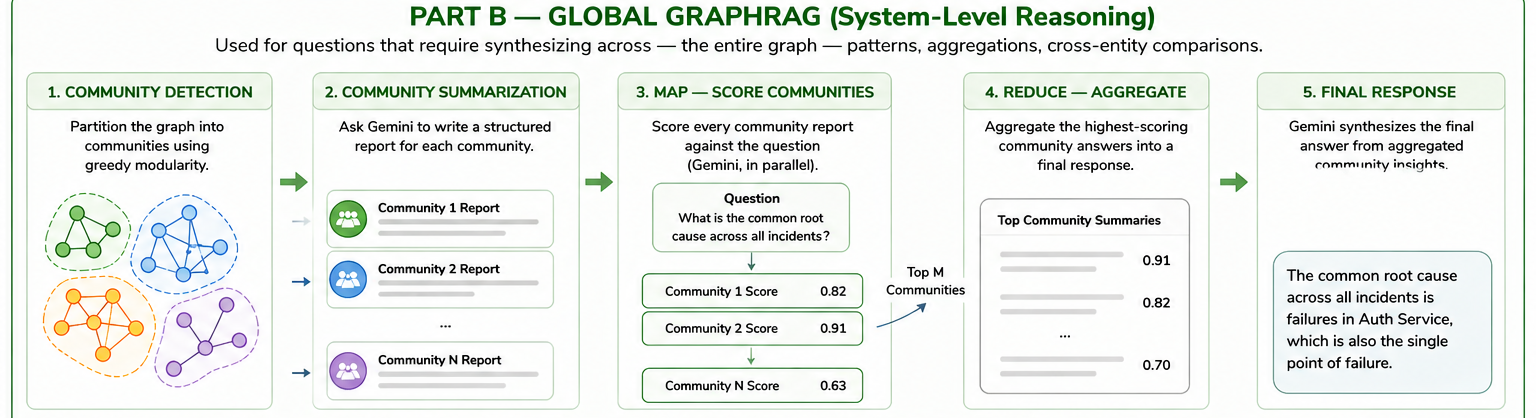

## Setup

In [ ]:
!pip install -q networkx sentence-transformers google-genai matplotlib

In [ ]:
import json
import os
import re
import numpy as np
import networkx as nx
import networkx.algorithms.community as nx_community
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict
from sentence_transformers import SentenceTransformer
import torch
from transformers import pipeline

from google import genai

print("Libraries ready.")

In [ ]:
# Load API keys (Colab Secrets or environment)

try:
    from google.colab import userdata

    GEMINI_API_KEY = userdata.get('GOOGLE_API_KEY')
    HF_TOKEN = userdata.get('HF_TOKEN')

    print("API keys loaded from Colab Secrets.")

except Exception:
    GEMINI_API_KEY = os.getenv('GOOGLE_API_KEY', '')
    HF_TOKEN = os.getenv('HF_TOKEN', '')

    print("Colab Secrets not available — reading from environment.")

client = genai.Client(api_key=GEMINI_API_KEY)

print("Gemini client ready.")


In [ ]:
import pathlib
import shutil
import urllib.request

REPO_RAW_BASE = "https://raw.githubusercontent.com/AmmarMohanna/oreilly-agentic-graphrag/main"


def ensure_repo_asset(source_path, local_path=None):
    """Make a repo asset available in the current runtime.

    Works in Colab when only the notebook was opened, and also works from a
    local checkout when the companion files are already beside the notebook.
    """
    source = pathlib.Path(source_path)
    target = pathlib.Path(local_path or source.name)

    if target.exists():
        print(f"Found {target}")
        return target

    local_candidates = [
        source,
        pathlib.Path.cwd() / source.name,
        pathlib.Path.cwd() / source,
        pathlib.Path.cwd().parent / source,
    ]
    for candidate in local_candidates:
        if candidate.exists():
            shutil.copy(candidate, target)
            print(f"Copied {candidate} -> {target}")
            return target

    url = f"{REPO_RAW_BASE}/{source_path}"
    print(f"Downloading {url}")
    urllib.request.urlretrieve(url, target)
    print(f"Saved {target}")
    return target

GRAPH_FILE = ensure_repo_asset(
    "3.Graphrag/incident_knowledge_graph.graphml.xml",
    "incident_knowledge_graph.graphml",
)
ensure_repo_asset("3.Graphrag/community_summaries.json", "community_summaries.json")

G = nx.read_graphml(str(GRAPH_FILE))

print(f"Graph loaded: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print()

from collections import Counter
types = Counter(d.get('type', '?') for _, d in G.nodes(data=True))
for t, count in sorted(types.items()):
    print(f"  {t:<15} {count} nodes")


---

# Part A — Local GraphRAG

Local GraphRAG answers questions about specific entities by finding the relevant neighbourhood in the graph and generating an answer from that context.

The five-step pipeline is shown below.

```
  Question
     |
     v
[1] Embed question  ──cosine similarity──>  Seed nodes  (top-k closest nodes)
     |
     v
[2] BFS traversal from seeds  ──N hops──>  Subgraph  (nodes + edges)
     |
     v
[3] Re-rank every reached node against question  ──keep top-N──>  Ranked context
     |
     v
[4] Assemble structured context block  (nodes with properties + relationships)
     |
     v
[5] Gemini Model  ──grounded generation──>  Answer
```

##  Node Text Representation and Embedding

The first challenge is bridging natural language and graph nodes. A node named `"Auth Service"` is just a string — we need to convert it into a rich text description that captures its type, attributes, and neighbourhood so that sentence embeddings can match it meaningfully against a natural-language question.

`node_to_text()` builds that description by reading the node's properties and its immediate edge relationships from the graph.

In [ ]:

def node_to_text(node, data):
    parts = [node, data.get("type", "")]
    if "summary"     in data: parts.append(data["summary"])
    if "description" in data: parts.append(data["description"])
    if "valid_from" in data:
        vt     = data.get("valid_to")
        status = "active" if not vt else "rolled back"
        parts.append(f"{status} {data['valid_from']} to {vt or 'present'}")

    ntype = data.get("type", "")

    if ntype == "team":
        owned   = [v for _, v, d in G.out_edges(node, data=True) if d.get("rel") == "OWNS"]
        members = [u for u, _, d in G.in_edges(node,  data=True) if d.get("rel") == "MEMBER_OF"]
        deps    = [u for u, _, d in G.in_edges(node,  data=True) if G.nodes[u].get("type") == "deployment"]
        incs    = [u for u, _, d in G.in_edges(node,  data=True) if G.nodes[u].get("type") == "incident"]
        if owned:   parts.append(f"owns services: {', '.join(owned)}")
        if members: parts.append(f"team members: {', '.join(members)}")
        if deps:    parts.append(f"involved in {len(deps)} deployments: {', '.join(deps)}")
        if incs:    parts.append(f"involved in {len(incs)} incidents: {', '.join(incs)}")

    elif ntype == "service":
        owners     = [u for u, _, d in G.in_edges(node,  data=True) if d.get("rel") == "OWNS"]
        deps_on    = [v for _, v, d in G.out_edges(node, data=True) if d.get("rel") == "DEPENDS_ON"]
        dependents = [u for u, _, d in G.in_edges(node,  data=True) if d.get("rel") == "DEPENDS_ON"]
        caused     = [u for u, _, d in G.in_edges(node,  data=True) if d.get("rel") == "CAUSED_BY"]
        affected   = [u for u, _, d in G.in_edges(node,  data=True) if d.get("rel") == "AFFECTS"]
        if owners:     parts.append(f"owned by: {', '.join(owners)}")
        if deps_on:    parts.append(f"depends on: {', '.join(deps_on)}")
        if dependents: parts.append(f"upstream dependents: {', '.join(dependents)}")
        if caused:     parts.append(f"caused incidents: {', '.join(caused)}")
        if affected:   parts.append(f"affected by incidents: {', '.join(affected)}")

    elif ntype == "incident":
        caused_by = [v for _, v, d in G.out_edges(node, data=True) if d.get("rel") == "CAUSED_BY"]
        resolved  = [v for _, v, d in G.out_edges(node, data=True) if d.get("rel") == "RESOLVED_BY"]
        triggered = [u for u, _, d in G.in_edges(node,  data=True) if d.get("rel") == "TRIGGERED"]
        affects   = [v for _, v, d in G.out_edges(node, data=True) if d.get("rel") == "AFFECTS"]
        if caused_by: parts.append(f"caused by service: {', '.join(caused_by)}")
        if resolved:  parts.append(f"resolved by: {', '.join(resolved)}")
        if triggered: parts.append(f"triggered by deployment: {', '.join(triggered)}")
        if affects:   parts.append(f"affects services: {', '.join(affects)}")

    elif ntype == "deployment":
        deployed_by = [v for _, v, d in G.out_edges(node, data=True) if d.get("rel") == "DEPLOYED_BY"]
        deployed_to = [v for _, v, d in G.out_edges(node, data=True) if d.get("rel") == "DEPLOYED_TO"]
        triggered   = [v for _, v, d in G.out_edges(node, data=True) if d.get("rel") == "TRIGGERED"]
        resolves    = [v for _, v, d in G.out_edges(node, data=True) if d.get("rel") == "RESOLVES"]
        authored_by = [v for _, v, d in G.out_edges(node, data=True) if d.get("rel") == "AUTHORED_BY"]
        if deployed_by: parts.append(f"deployed by team: {', '.join(deployed_by)}")
        if deployed_to: parts.append(f"deployed to service: {', '.join(deployed_to)}")
        if triggered:   parts.append(f"triggered incidents: {', '.join(triggered)}")
        if resolves:    parts.append(f"resolved incidents: {', '.join(resolves)}")
        if authored_by: parts.append(f"authored by: {', '.join(authored_by)}")

    elif ntype in ("person", "engineer", "member"):
        authored  = [u for u, _, d in G.in_edges(node,  data=True) if d.get("rel") == "AUTHORED_BY"]
        member_of = [v for _, v, d in G.out_edges(node, data=True) if d.get("rel") == "MEMBER_OF"]
        resolved  = [u for u, _, d in G.in_edges(node,  data=True) if d.get("rel") == "RESOLVED_BY"]
        if member_of: parts.append(f"member of team: {', '.join(member_of)}")
        if resolved:  parts.append(f"resolved incidents: {', '.join(resolved)}")
        if authored:  parts.append(f"authored deployments: {', '.join(authored)}")

    return " ".join(parts)


# Embed every node once — reused for all local queries
print("Loading sentence encoder...")
encoder = SentenceTransformer("all-MiniLM-L6-v2")

node_names = list(G.nodes())
node_texts = [node_to_text(n, G.nodes[n]) for n in node_names]
node_embeddings = encoder.encode(node_texts, normalize_embeddings=True)

print(f"Embedded {len(node_names)} nodes.")
print()
print("Sample node text:")
print(f"  {node_texts[0]}")

## Local Retrieval Functions

Four functions implement steps 1 through 4 of the local pipeline:

- `find_seeds` — cosine similarity between the question and all node embeddings
- `traverse` — BFS expansion from seeds in both directions
- `rank_nodes` — re-score every reached node against the question
- `assemble_context` — format top nodes and their edges into a context string

In [ ]:
def find_seeds(question, top_k=3):
    """
    Step 1 — seed strategy: name match first, embedding search second.
    Any node whose name appears verbatim in the question is pinned as a seed.
    Remaining slots are filled by cosine similarity.
    """
    q_lower = question.lower()

    # Direct name match — never drops explicitly mentioned entities
    direct = [(n, 1.0) for n in node_names if n.lower() in q_lower]

    # Embedding similarity for the rest
    q_emb  = encoder.encode([question], normalize_embeddings=True)
    scores = np.dot(node_embeddings, q_emb.T).flatten()
    ranked = [(node_names[i], float(scores[i])) for i in scores.argsort()[::-1]]

    # Merge: direct first, then vector, deduplicate
    seen, seeds = set(), []
    for n, s in direct + ranked:
        if n not in seen:
            seen.add(n)
            seeds.append((n, s))
    return seeds[:top_k]


# ---- TEST ----
question = "Data"

seeds = find_seeds(question)

print("=== SEEDS ===")
for n, s in seeds:
    print(n, s)

In [ ]:
def traverse(seeds, hops=2):
    """Step 2 — BFS expansion from seed nodes."""

    frontier = {n for n, _ in seeds}
    all_nodes = set(frontier)
    seen_edges = set()
    all_edges = []

    for _ in range(hops):
        next_frontier = set()

        for node in frontier:

            for u, v, d in G.out_edges(node, data=True):
                key = (u, v, d.get("rel"))
                if key not in seen_edges:
                    seen_edges.add(key)
                    all_edges.append(key)
                next_frontier.add(v)

            for u, v, d in G.in_edges(node, data=True):
                key = (u, v, d.get("rel"))
                if key not in seen_edges:
                    seen_edges.add(key)
                    all_edges.append(key)
                next_frontier.add(u)

        frontier = next_frontier - all_nodes
        all_nodes |= frontier

        if not frontier:
            break

    return all_nodes, all_edges


# Single seed input
seeds = [("Data Engineering Team", 1.0)]

# Run traversal
nodes, edges = traverse(seeds, hops=2)

# ---- OUTPUT ----
print("=== TRAVERSAL TEST (Single Seed) ===")
print("Seed:", seeds)

print("\nNodes found:", len(nodes))
print("Edges found:", len(edges))

print("\nSample nodes:")
print(list(nodes)[:10])

print("\nSample edges:")
print(edges[:5])

In [ ]:
def rank_nodes(nodes, question):
    """Step 3 — re-score nodes against query."""

    valid_nodes = [n for n in nodes if n in node_names]
    idxs = [node_names.index(n) for n in valid_nodes]

    q_emb = encoder.encode([question], normalize_embeddings=True)

    scores = np.dot(node_embeddings[idxs], q_emb.T).flatten()

    ranked = sorted(
        zip(valid_nodes, scores),
        key=lambda x: -x[1]
    )

    return ranked


# ---- TEST ----
ranked = rank_nodes(nodes, question)

print("=== RANKED NODES ===")
for n, s in ranked[:10]:
    print(n, s)

In [ ]:
def assemble_context(ranked, edges, top_n=8):
    top_nodes = {n for n, _ in ranked[:top_n]}

    # ── Node attributes (includes timestamps) ─────────────────────────────
    lines = ["[ NODES ]"]
    for node, score in ranked[:top_n]:
        data = G.nodes[node]
        line = f"  {node} ({data.get('type', '?')})"
        if "summary"    in data: line += f"  — {data['summary']}"
        if "valid_from" in data:
            vt     = data.get("valid_to")
            status = "ACTIVE" if not vt else "ROLLED BACK"
            line  += f"  [{status}: {data['valid_from']} → {vt or 'present'}]"
        lines.append(line)

    # ── Relationships ──────────────────────────────────────────────────────
    lines.append("\n[ RELATIONSHIPS ]")
    seen = set()
    for u, v, rel in edges:
        if (u in top_nodes or v in top_nodes) and (u, v, rel) not in seen:
            lines.append(f"  {u}  --[{rel}]-->  {v}")
            seen.add((u, v, rel))

    return "\n".join(lines)

# ---- TEST ----
context = assemble_context(ranked, edges)
print(context)

## The Local GraphRAG Function

`local_graphrag()` runs all five steps and prints each one so you can see exactly what the pipeline does at every stage — which seeds were selected, how many nodes were reached, which were ranked highest, what context was assembled, and what Gemini generated from it.

In [ ]:
def local_graphrag(question, k_seeds=3, hops=2, top_n=8):
    """
    Full Local GraphRAG pipeline:
    Seed finding -> Graph traversal -> Re-ranking -> Context assembly -> Gemini generation.
    Prints every intermediate step.
    """
    divider = "=" * 72
    print(divider)
    print(f"QUESTION: {question}")
    print(divider)

    # Step 1: Seed nodes
    seeds = find_seeds(question, top_k=k_seeds)
    print(f"\nSTEP 1 — SEED NODES  (top {k_seeds} by cosine similarity)")
    print("-" * 72)
    for node, score in seeds:
        ntype = G.nodes[node].get('type', '?')
        print(f"  [{ntype}]  {node}  (score: {score})")

    # Step 2: Traversal
    nodes, edges = traverse(seeds, hops=hops)
    print(f"\nSTEP 2 — GRAPH TRAVERSAL  ({hops} hops)")
    print("-" * 72)
    print(f"  Reached: {len(nodes)} nodes, {len(edges)} edges")

    # Step 3: Re-rank
    ranked = rank_nodes(nodes, question)
    print(f"\nSTEP 3 — RE-RANKED TOP {top_n}")
    print("-" * 72)
    for node, score in ranked[:top_n]:
        ntype = G.nodes[node].get('type', '?')
        print(f"  [{ntype}]  {node}  ({round(float(score), 3)})")

    # Step 4: Assemble context
    context = assemble_context(ranked, edges, top_n=top_n)
    print(f"\nSTEP 4 — ASSEMBLED CONTEXT  ({len(context)} chars)")
    print("-" * 72)
    print(context)

    # Step 5: Generate
    prompt = (
        "You are an expert SRE analyst. "
        "Use only the knowledge graph context below to answer the question. "
        "Be specific — cite node names, relationship types, and timestamps where relevant. "
        "Do not add information not present in the context.\n\n"
        f"{context}\n\n"
        f"Question: {question}\n\nAnswer:"
    )
    response = client.models.generate_content(
        model='gemini-3-flash-preview',
        contents=prompt
    )

    print(f"\nSTEP 5 — GEMINI ANSWER")
    print("-" * 72)
    print(response.text)
    print(divider)


print("local_graphrag() ready.")

## Local Queries
We run the queries that benefit from local entity-level retrieval. Compare the answers here to what Vector RAG returned in Notebook 1.

In [ ]:
local_graphrag(
    "Which team owns the service that API Gateway depends on?",
    k_seeds=2, hops=2, top_n=8
)

In [ ]:
local_graphrag(
    "What was the last deployment made before INC-003 was opened,and which teams were responsible?",
    k_seeds=2, hops=3, top_n=6
)

### To do: Try Tuning one operator (hop limit,top k) and report the impact on one question.

---

# Part B — Global GraphRAG

Local GraphRAG works well when the answer lives in the neighbourhood of a few specific nodes. But Query 4 — *"What is the common root cause pattern across all three incidents?"* — requires reading the entire graph and identifying patterns that span multiple communities.

Local traversal from a few seed nodes will never reach all three incidents and all their causes simultaneously. We need a different strategy.

**Global GraphRAG** solves this with a map-reduce approach:

```
AT indexing
[1] Community detection
       Partition graph into clusters using greedy modularity
       Each community = a coherent sub-domain (e.g. Auth cluster, Gateway cluster)

[2] Community summarization
       Gemini (local model) reads each community's nodes + edges and writes a structured report
       Reports are cached to avoid re-generating on every query

At query level
[1] Map — score all communities against the question
       Gemini reads each community report and returns a (response, score 0-10) pair
       Communities that have no relevant information return score 0

[2] Reduce — aggregate high-scoring answers
       Collect all communities with score >= threshold
       Gemini synthesizes them into a single final answer
```

##  Community Detection

We partition the graph using **greedy modularity** — a fast algorithm that finds clusters of nodes that are more densely connected to each other than to the rest of the graph. Each community naturally groups related services, teams, deployments, and incidents together.

In [ ]:
undirected   = G.to_undirected()
communities  = list(nx_community.greedy_modularity_communities(undirected))

print(f"Communities detected: {len(communities)}")
print()

TYPE_COLORS = {
    "service":    "#4C9BE8",
    "team":       "#E8914C",
    "member":     "#6DBE6D",
    "incident":   "#E86B6B",
    "deployment": "#B87FE8",
}

for i, comm in enumerate(communities):
    by_type = defaultdict(list)
    for node in sorted(comm):
        ntype = G.nodes[node].get('type', '?')
        by_type[ntype].append(node)
    print(f"Community {i}  ({len(comm)} nodes)")
    for ntype, nodes in sorted(by_type.items()):
        print(f"  [{ntype}]  {', '.join(nodes)}")
    print()

### Community Visualization

The plot below colors nodes by their detected community rather than their type, so you can see which sub-domains the algorithm identified.

In [ ]:
COMM_COLORS = ["#4C9BE8", "#E8914C", "#6DBE6D", "#E86B6B", "#B87FE8", "#F7DC6F"]

node_to_comm = {}
for i, comm in enumerate(communities):
    for node in comm:
        node_to_comm[node] = i

node_colors = [COMM_COLORS[node_to_comm.get(n, 0) % len(COMM_COLORS)] for n in G.nodes]

plt.figure(figsize=(14, 9))
plt.title("Knowledge Graph — Colored by Community", fontsize=13, fontweight="bold", pad=12)
pos = nx.spring_layout(G, seed=42, k=2.2)

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1600, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=7, font_weight="bold")
nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=12,
                       edge_color="#aaaaaa", width=0.8,
                       connectionstyle="arc3,rad=0.08")

legend = [mpatches.Patch(color=COMM_COLORS[i], label=f"Community {i}")
          for i in range(len(communities))]
plt.legend(handles=legend, loc="upper left", fontsize=9)
plt.axis("off")
plt.tight_layout()
plt.show()

## Community Summarization

For each community we collect all node properties and edge relationships into a structured text block, then ask a **local language model** (Qwen2.5-1.5B-Instruct) to produce a narrative report.

Running summarization locally has two advantages:

- **No API quota consumed** during the bulk indexing phase — useful when you have many communities.
- **Offline caching** — summaries are written to `community_summaries.json` so re-runs skip inference entirely.

The map-reduce scoring and the final synthesized answer use the Gemini API,
but only for the small number of community reports that pass the relevance threshold.


In [ ]:
# LOCAL LLM SETUP
# Community summarization (the indexing phase) runs entirely on a local model.
# This keeps bulk inference offline, avoids API quota, and can be cached.
# Only the map-reduce scoring and final answer use the Gemini API.

LOCAL_MODEL = "Qwen/Qwen2.5-1.5B-Instruct"
# Alternatives:
#   "Qwen/Qwen2.5-3B-Instruct"        -- better quality, ~3 GB VRAM
#   "microsoft/Phi-3.5-mini-instruct" -- strong reasoning, ~4 GB VRAM

_device    = 0 if torch.cuda.is_available() else -1
_dtype     = torch.float16 if torch.cuda.is_available() else torch.float32

_pipe = pipeline(
    "text-generation",
    model            = LOCAL_MODEL,
    device           = _device,
    torch_dtype      = _dtype,
    trust_remote_code = True,
)

def local_generate(prompt: str, max_new_tokens: int = 512) -> str:
    """Run one inference call through the local HuggingFace model."""
    messages = [{"role": "user", "content": prompt}]
    out = _pipe(
        messages,
        max_new_tokens = max_new_tokens,
        temperature    = 0.1,
        do_sample      = True,
    )
    return out[0]["generated_text"][-1]["content"]

print(f"Local LLM ready -- {LOCAL_MODEL}  ({'GPU' if _device == 0 else 'CPU'})")

In [ ]:
CACHE_PATH = "community_summaries.json"


def collect_community_text(community):
    """Serialize a community's nodes and edges into a plain-text block."""
    lines = []
    comm_set = set(community)

    for node in sorted(community):
        d     = G.nodes[node]
        ntype = d.get('type', '?')
        vf    = d.get('valid_from', '')
        vt    = d.get('valid_to', '')
        desc  = d.get('summary', '') or d.get('description', '')
        line  = f"NODE {node} [{ntype}]"
        if vf:   line += f"  from={vf}"
        if vt:   line += f"  to={vt} [ROLLED BACK]"
        if desc: line += f"  | {str(desc)[:120]}"
        lines.append(line)

    for node in sorted(community):
        for neighbor in undirected.neighbors(node):
            if neighbor in comm_set:
                ed  = G.edges.get((node, neighbor)) or G.edges.get((neighbor, node)) or {}
                rel = ed.get('rel', '')
                lines.append(f"EDGE {node} -> {neighbor} [{rel}]")

    return "\n".join(lines)


def summarize_community(text):
    """Ask the local LLM to write a structured report for one community."""
    prompt = (
        "You are an AI assistant that analyzes a COMMUNITY inside a platform knowledge graph.\n\n"
                "Goal: Write a concise COMMUNITY REPORT from relationships between services, teams, "
                "deployments, incidents, and infrastructure.\n\n"
                "The report MUST include these sections:\n\n"
                "TITLE: short name identifying the key services and teams\n\n"
                "SUMMARY: how entities are connected and what this part of the platform does\n\n"
                "TIMELINE: list every deployment and incident in chronological order by valid_from date. "
                "For each entry write: date, what changed, which team, and whether it is ACTIVE (valid_to=None) "
                "or ROLLED BACK (valid_to is set). "
                "Example: 2026-04-11 08:30 — API Gateway v3.2.1 deployed by Platform Team [ROLLED BACK 2026-04-11 10:12]\n\n"
                "DETAILED FINDINGS: 5–8 key insights covering:\n"
                "- Which deployments caused which incidents (causation chain with dates)\n"
                "- Which deployments were rolled back and why\n"
                "- Service dependencies that amplified failures\n"
                "- Team ownership and on-call responsibilities\n"
                "- Risks and patterns across this community\n\n"
                "Rules:\n"
                "- Always include exact dates from valid_from and valid_to fields\n"
                "- Never omit rolled-back deployments — they are the most important signal\n"
                "- Write like an internal engineering post-mortem. Synthesize — do not just list facts."
                "Community data:\n" + text
    )
    return local_generate(prompt)


def build_community_summaries(communities):
    summaries = {}
    for i, comm in enumerate(communities):
        print(f"  Summarizing community {i} ({len(comm)} nodes)...")
        text        = collect_community_text(comm)
        summaries[i] = summarize_community(text)
        print(f"    done ({len(summaries[i])} chars)")
    return summaries


# Load from cache if available, otherwise generate
if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH) as f:
        community_summaries = {int(k): v for k, v in json.load(f).items()}
    print(f"Loaded {len(community_summaries)} cached community summaries.")
else:
    print("No cache found — generating summaries with local LLM (Qwen2.5-1.5B, takes a few minutes)...")
    community_summaries = build_community_summaries(communities)
    with open(CACHE_PATH, 'w') as f:
        json.dump({str(k): v for k, v in community_summaries.items()}, f, indent=2)
    print(f"Saved to {CACHE_PATH}")

In [ ]:
# Display the first 400 characters of each community summary
print("=" * 72)
print("COMMUNITY SUMMARIES")
print("=" * 72)

for i, summary in community_summaries.items():
    comm = list(communities[i])
    by_type = defaultdict(list)
    for node in sorted(comm):
        by_type[G.nodes[node].get('type', '?')].append(node)

    print(f"\nCommunity {i}  ({len(comm)} nodes)")
    for ntype, nodes in sorted(by_type.items()):
        print(f"  [{ntype}]  {', '.join(nodes)}")
    print(f"  Summary preview: {summary[:400].strip()}...")
    print()

## Global Query Engine — Map-Reduce

The map step sends each community report to Gemini with the question and asks for a (response, score) pair. The reduce step collects all reports that scored above a threshold and asks Gemini to synthesize them into a single final answer.

This is the same map-reduce pattern used in Microsoft's original GraphRAG paper.

In [ ]:
def score_community(summary, question):
    """
    Map step: ask Gemini to score one community report against the question.
    Returns (response_text, score_int).
    """
    prompt = (
        "You are analyzing a community report from a knowledge graph.\n"
        "Determine how relevant this community is to the question below.\n\n"
        f"Community report:\n{summary}\n\n"
        f"Question: {question}\n\n"
        "Respond with valid JSON only — no other text:\n"
        '{"response": "<your answer from this community>", "score": <integer 0-10>}'
    )
    raw = client.models.generate_content(
        model='gemini-3-flash-preview',
        contents=prompt
    ).text.strip()

    # Try direct JSON parse
    try:
        result = json.loads(raw)
        return result.get('response', raw), int(result.get('score', 0))
    except Exception:
        pass

    # Try regex extraction if the model added surrounding text
    match = re.search(r'\{[^{}]*"response"[^{}]*"score"[^{}]*\}', raw, re.DOTALL)
    if match:
        try:
            result = json.loads(match.group())
            return result.get('response', raw), int(result.get('score', 0))
        except Exception:
            pass

    # Fallback: keyword overlap heuristic
    overlap = len(set(question.lower().split()) & set(raw.lower().split()))
    return raw, min(overlap, 5) if len(raw) > 30 else 0


def global_graphrag(question, score_threshold=3):
    """
    Full Global GraphRAG pipeline:
    Map (score all communities) -> Filter -> Reduce (aggregate top answers).
    """
    divider = "=" * 72
    print(divider)
    print(f"QUESTION: {question}")
    print(divider)

    # Map
    print(f"\nSTEP 1 — MAP: scoring {len(community_summaries)} communities")
    print("-" * 72)
    scored = []
    for cid, summary in community_summaries.items():
        response, score = score_community(summary, question)
        scored.append((cid, score, response))
        print(f"  Community {cid}: score={score}/10  |  {response[:80]}...")

    # Filter
    relevant = [(cid, s, r) for cid, s, r in scored if s >= score_threshold]
    print(f"\nSTEP 2 — FILTER: {len(relevant)}/{len(scored)} communities scored >= {score_threshold}")

    if not relevant:
        print("  No community had sufficient information.")
        return

    # Reduce
    relevant.sort(key=lambda x: -x[1])
    combined = "\n".join(f"[score={s}/10] {r}" for _, s, r in relevant)

    reduce_prompt = (
        "You are an expert SRE analyst. "
        "The answers below were each generated from a different community of a knowledge graph, "
        "scored by relevance to the question. "
        "Synthesize them into a single comprehensive final answer. "
        "Prioritize higher-scored answers. Be specific and cite evidence.\n\n"
        f"Question: {question}\n\n"
        f"Community answers:\n{combined}\n\n"
        "Final answer:"
    )

    final = client.models.generate_content(model='gemini-3-flash-preview', contents=reduce_prompt)

    print(f"\nSTEP 3 — REDUCE: GEMINI AGGREGATED ANSWER")
    print("-" * 72)
    print(final.text)
    print(divider)


print("global_graphrag() ready.")

## Global Query
 Global GraphRAG reads every community report and produces a grounded narrative answer.

In [ ]:
global_graphrag(
    "What is the common root cause pattern across all three incidents, "
    "and which service is the single point of failure?"
)

---

## Summary — Local vs Global GraphRAG

| | Local GraphRAG | Global GraphRAG |
|---|---|---|
| **Retrieval method** | Cosine seed finding + BFS traversal | Community detection + per-community LLM scoring |
| **Context source** | Neighbourhood of specific entities | Full graph partitioned into communities |
| **Best for** | Specific entity questions, multi-hop chains | Cross-entity patterns, synthesis, aggregation |
| **Latency** | Fast — one embedding lookup + BFS | Slower — one LLM call per community |
| **Query 1 (local lookup)** | Correct | Overkill — community reports are too broad |
| **Query 2 (multi-hop)** | Correct — chain traversed in 2 hops | Possible but imprecise |
| **Query 3 (temporal)** | Correct — timestamps in context | Community reports include timeline |
| **Query 4 (global synthesis)** | Incomplete — seeds miss distant incidents | Correct — all communities scored |

### When to Use Each

Use **Local GraphRAG** when the question names or implies a specific entity — a service, a team, an incident ID, a deployment version.

Use **Global GraphRAG** when the question asks for patterns, comparisons, or summaries that span the entire system — root cause analysis across multiple incidents, cross-team risk assessment, systemic dependency audit.

A production Agentic GraphRAG system would route automatically: detect whether the question is local or global, then call the appropriate retrieval strategy.

***In the next session, we will make the graph agent agentic so it can route our queries.***